In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re # Regular Expression untuk cleaning
import nltk

# Download resource bahasa (hanya perlu dijalankan sekali)
nltk.download('stopwords')
nltk.download('punkt')

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


Load Dataset

In [6]:
df = pd.read_csv('IMDB Dataset.csv')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [9]:
print("\nJumlah sentimen:", df['sentiment'].value_counts())
df = df.iloc[:10000]


Jumlah sentimen: sentiment
positive    5028
negative    4972
Name: count, dtype: int64


Text Preprocessing

Fungsi cleaning standar:
1. Lowercasing: Ubah ke huruf kecil.
2. emove Punctuation: Hapus tanda baca/angka/emoji.
3. Remove Stopwords: Hapus kata umum yang tidak bermakna (is, am, the, of).
4. Stemming: Memotong imbuhan (misal: "running" -> "run").

In [10]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # 1. Hapus HTML tag (jika ada, misal <br>)
    text = re.sub(r'<.*?>', '', text)
    # 2. Hapus tanda baca & angka (hanya ambil huruf a-z)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    # 3. Ubah ke huruf kecil
    text = text.lower()
    # 4. Tokenization (pecah kalimat jadi kata-kata)
    words = text.split()
    # 5. Hapus Stopwords & Lakukan Stemming
    words = [stemmer.stem(word) for word in words if word not in stop_words]
    # 6. Gabung lagi jadi kalimat
    return ' '.join(words)

# Terapkan ke seluruh data (Mungkin butuh waktu agak lama)
print("Sedang membersihkan data...")
df['clean_review'] = df['review'].apply(clean_text)
print("Selesai! Contoh hasil:")
print(df[['review', 'clean_review']].head())

Sedang membersihkan data...
Selesai! Contoh hasil:
                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                        clean_review  
0  one review mention watch oz episod hook right ...  
1  wonder littl product film techniqu unassum old...  
2  thought wonder way spend time hot summer weeke...  
3  basic famili littl boy jake think zombi closet...  
4  petter mattei love time money visual stun film...  


Split Data & Vectorization (TF-IDF)

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# X adalah teks yang sudah bersih, y adalah label sentimen
X = df['clean_review']
y = df['sentiment'].map({'positive': 1, 'negative': 0}) # Ubah target jadi angka

# Split Data (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Vectorization (Ubah kata jadi angka)
vectorizer = TfidfVectorizer(max_features=5000) # Ambil 5000 kata terpenting saja
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Ukuran Matrix TF-IDF:", X_train_tfidf.shape)

Ukuran Matrix TF-IDF: (8000, 5000)


Modeling (Naive Bayes)

In [12]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

# Prediksi
y_pred = model.predict(X_test_tfidf)
print("Model selesai dilatih")

Model selesai dilatih


Akurasi: 0.851

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.85      0.85       996
           1       0.85      0.85      0.85      1004

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



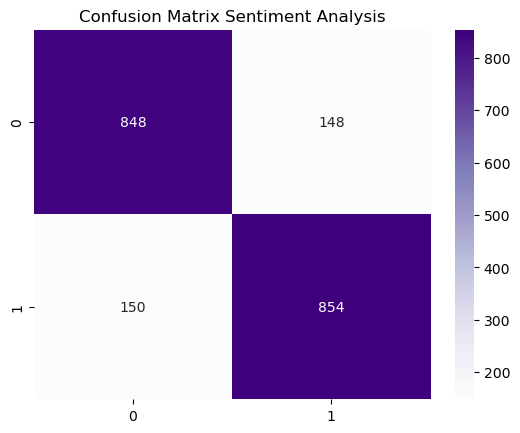

In [13]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Akurasi:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Visualisasi Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix Sentiment Analysis')
plt.show()

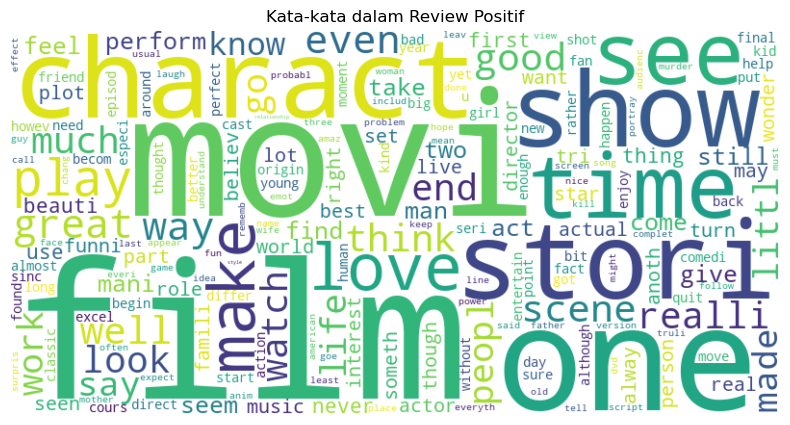

In [16]:
from wordcloud import WordCloud

# Gabungkan semua review positif
pos_text = " ".join(df[df['sentiment']=='positive']['clean_review'])

# Buat WordCloud
wc = WordCloud(width=800, height=400, background_color='white').generate(pos_text)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Kata-kata dalam Review Positif')
plt.show()